**Backpropagation** is the algorithm that allows you to efficiently evaluate the gradient of some kind of a loss function with respect to the weights of a neural network and what that allows us to do is that we can iteratively tune the weights of the neural network to minimize the loss function and therefore improve the accuracy of the network, so the backpropagation would be at the mathematical core of any modern deep neural network library like say PyTorch etc.

**Neural networks** are just mathematical expressions and they take the input data as an input and they take the weights of neural network as an input and it's a mathematical expression and the output are predictions of our neural net.
We use the machinery of backpropagation for training neural nets.

In [1]:
!pip install micrograd

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

In [4]:
f(3.0)


20.0

In [5]:
# Let's plot the function
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

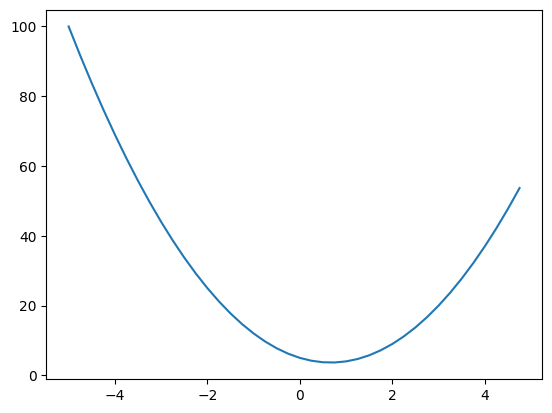

In [7]:
plt.plot(xs, ys)

Now we should look up the definition of derivative and understand what derivative is measuring and what it's telling us about the function.

$\lim_{h \to 0} \frac{f(a+h) - f(a)}{h}$

So what it's saying if we slightly bump up at some point x it means slightly increase it by small number h how does the function respond, with what sensitivity does it respond, what is the slope at that point.
We can basically evaluate the derivative numerically by taking a very small h.



In [8]:
h = 0.000001
x = 3.0
(f(x + h) - f(x))/h
# With this approach we see that at point 3 the slope is 14
# If we deferentiate f(x) we will get 6*x - 4 -> 6*3 - 4 = 14

14.000003002223593

In [9]:
h = 0.000001
x = -3.0
(f(x + h) - f(x))/h
# With this approach we see that at point -3 the slope is 22

-21.999997002808414

In [10]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [11]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


Now a, b and c are some specific values three inputs into our expression graph and a single output d. Let's look at the derivatives of d with respect to a, b and c.

In [12]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [13]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
  def __repr__(self):
    return f"Value(data={self.data})"
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out
  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    return out


In [14]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


In [15]:
a = Value(2.0, 'a')
b = Value(-3.0, 'b')
c = Value(10.0, 'c')
d = a * b + c
d.label = 'd'
print(d)
d._prev
d._op

Value(data=4.0)


'+'

**Expression visualization**

In [16]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

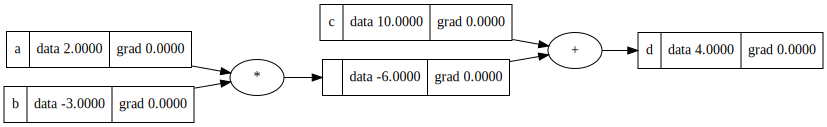

In [17]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
d = a * b + c
d.label = 'd'
draw_dot(d)

In [18]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c;
d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

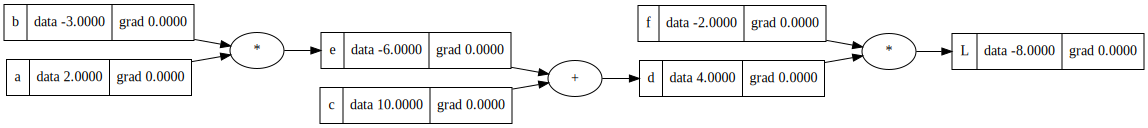

In [19]:
draw_dot(L)

 This is visualizing the forward pass of neural net so the output of the forward pass is L.data = -8.0. We created a variable inside the Value class that maintains the derivative of L with respect to that value and call that variable grad and initially it will be 0.

**Let's now do backpropagation manually and filling in gradients.**

In [20]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [21]:
L = d * f

$$
\frac{dL}{dd} = ? \;\;\Rightarrow\;\; \frac{dL}{dd} = f
$$

$$
\frac{f(x+h)-f(x)}{h}
$$

$$
\frac{(d+h)\,f - d\,f}{h}
= \frac{d f + h f - d f}{h}
= f
$$

$\text{So symmetrically: }\frac{dL}{df} = d$


$$
\frac{dL}{dc} = ?
$$

$$
\frac{dd}{dc} = ? \quad\text{where } d = c + e \Rightarrow \frac{dd}{dc} = 1.0
$$

$$
\frac{f(x+h)-f(x)}{h}
$$

$$
\frac{(c + h + e) - (c + e)}{h}
= \frac{c + h + e - c - e}{h}
= 1.0
$$

$\text{So symmetrically }\frac{dd}{de} = 1.0, \text{but we want }\frac{dL}{dc}$.  

$\text{Using the Chain Rule: }
\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}
$


$$
\frac{dL}{dc} = \frac{dL}{dd} * \frac{dd}{dc}
$$



$$
\frac{dL}{de} = -2.0
$$

$$
\frac{dL}{da} = \frac{dL}{de} \cdot \frac{de}{da}
$$

$$
\frac{de}{da} = b,
$$

$$
\frac{dL}{da} = -2.0 \times -3.0.
$$


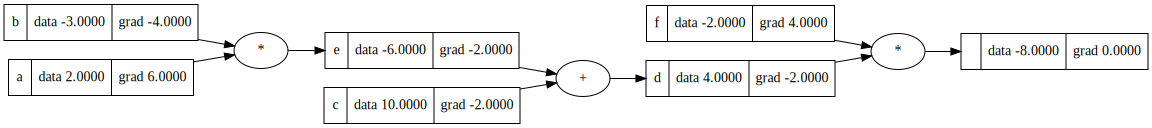

In [22]:
draw_dot(L)

In [23]:
# Using this function to verify if we have got right gradients.
def lol():
  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a * b; e.label = 'e'
  d = e + c;
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a * b; e.label = 'e'
  # e.data += h
  d = e + c;
  d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1) / h)

lol()

0.0


So backpropagation it's just a recursive application of Chain Rule backwards through the computation graph. How to do single optimization step.

We are going to nudge our inputs to try to make L go up, so if we want L go up that means we have to go in the direction of the gradient by like some small step amount.

In [24]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print(L.data) # Because we go in the direction of grad we expect it to go up

-7.286496


# Example 2 of backpropagation

**What is a Neuron?**

We take all the input values x, multiply them by their corresponding weights, add the bias, and then pass the result through an activation function. This activation function is a type of squashing function, such as a sigmoid, tanh, or something similar.


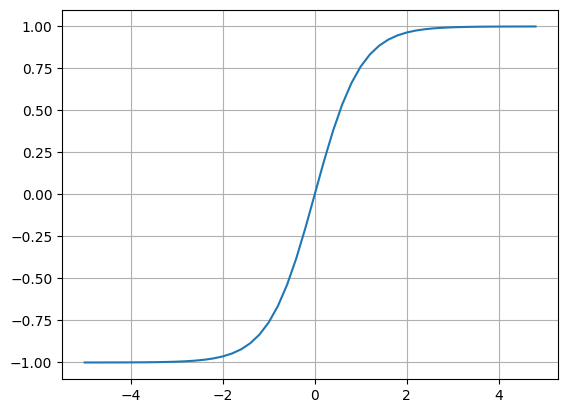

In [25]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

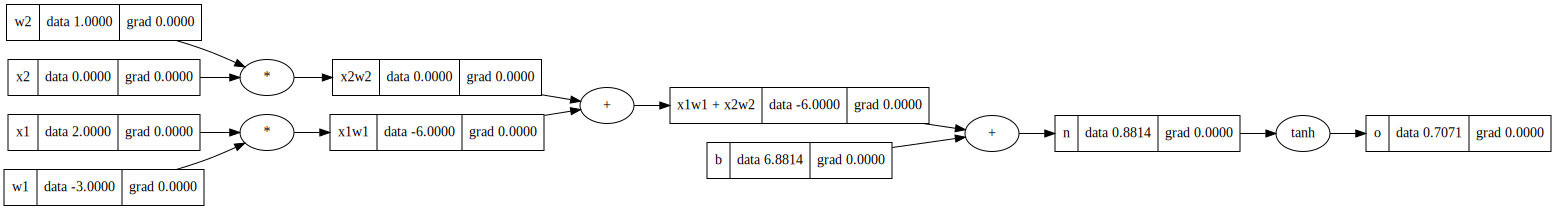

In [26]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
draw_dot(o)

Now we are going to fill in all the gradients. So what is the derivative of o with respect to all the inputs. And of course in the typical neural net setting what we really care about the most is the derivative of these neurons with respect to weights(In this case we have one neuron). Eventually there is a Loss function that measures the accuracy of the neural net and we are backpropagating with respect to weights and trying to increase that accuracy.

In [27]:
o.grad = 1.0
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2
n.grad = 1.0 - o.data**2
x1w1x2w2.grad = n.grad
b.grad = n.grad
x2w2.grad = n.grad
x1w1.grad = n.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

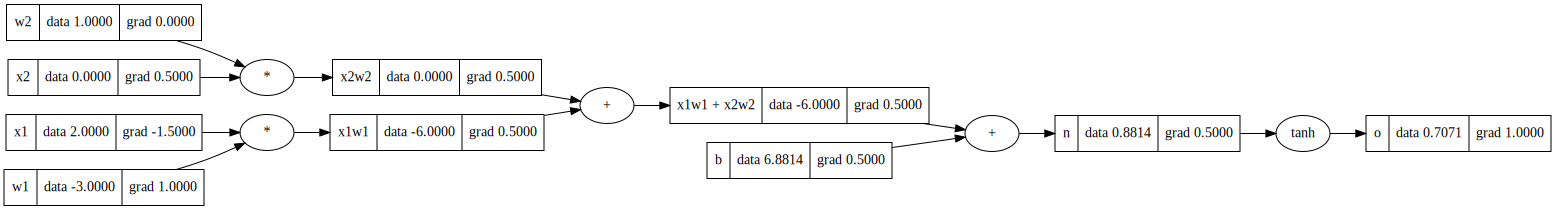

In [28]:
draw_dot(o)

After implementing backward function.

In [46]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

In [56]:
o.grad = 1.0

In [57]:
o._backward()

In [58]:
n._backward()

In [59]:
b._backward()

In [60]:
x1w1x2w2._backward()

In [61]:
x2w2._backward()
x1w1._backward()

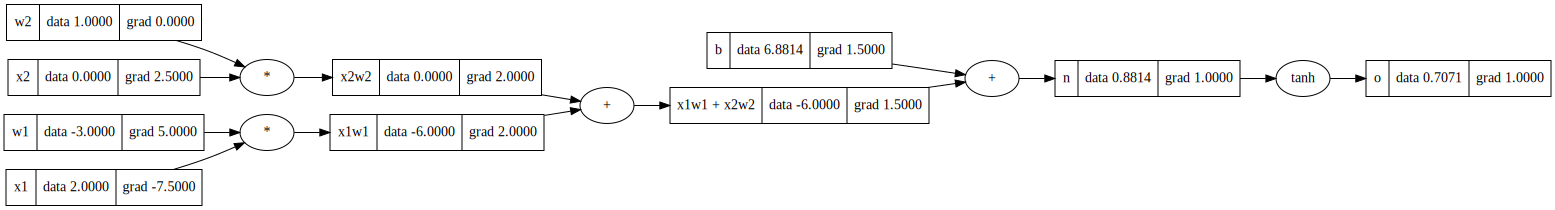

In [62]:
draw_dot(o)

In [64]:
# o.backward()

In [69]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

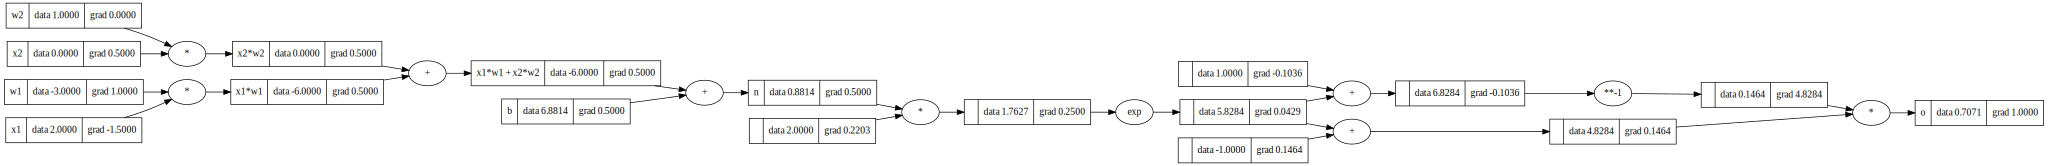

In [70]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

Micrograd is a scalar valued engine, but in PyTorch everything is based around tensors. **Tensors** are just n-dimensional arrays of scalars. Casting to double because python is by default using double precision for it's floating point numbers.

In [71]:
import torch

In [72]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [73]:
torch.Tensor([[1, 2, 3], [4, 5, 6]]).shape


torch.Size([2, 3])

In [74]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [75]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

Let's start building out a neural net piece by piece and eventually we will build out a two-layer multi-layer perceptron. But we will do it using PyTorch.

In [76]:
import random

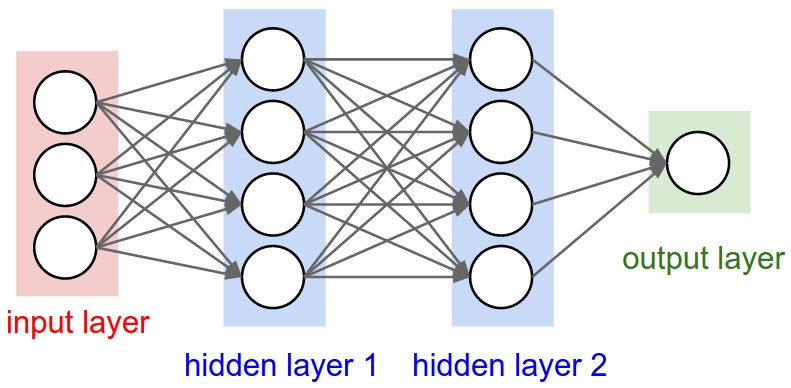

In [80]:
class Neuron:

  def __init__(self, nin):
    # nin - number of inputs
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  def __call__(self, x):
    # w * x + b
    # zip in python takes 2 iterators and it creates a new iterator that iterates over the tuples of the corresponding entries
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs


class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x


x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.9602398086033679)

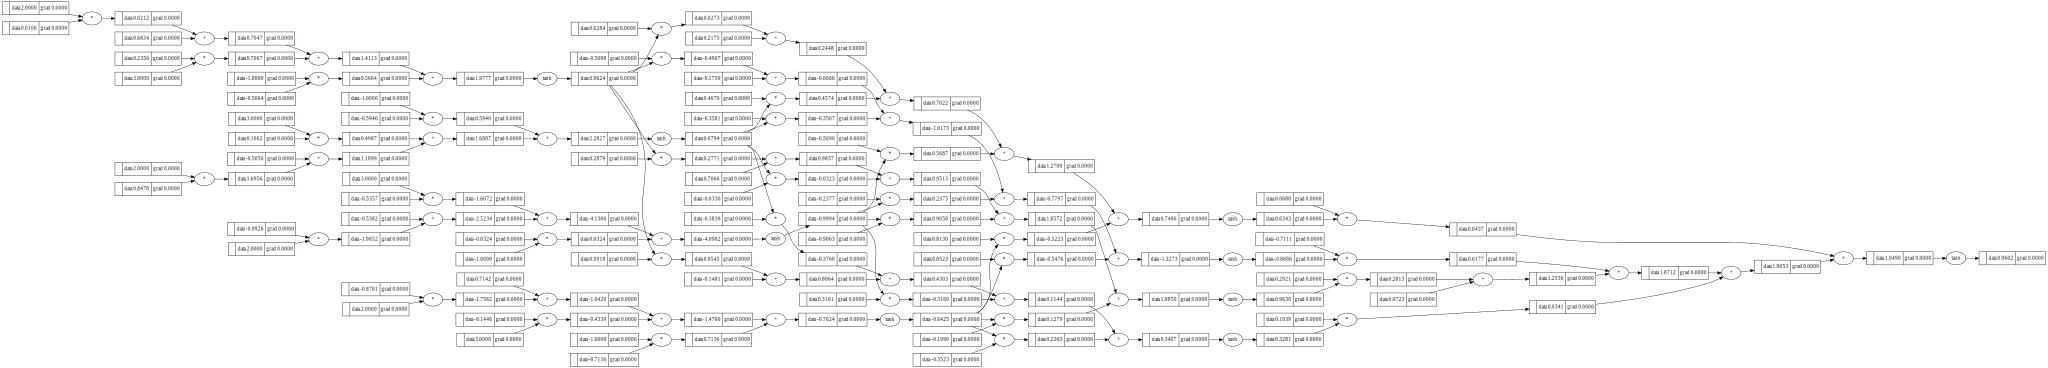

In [81]:
draw_dot(n(x))

In [83]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9602398086033679),
 Value(data=0.9508837273896271),
 Value(data=0.9152208092467237),
 Value(data=0.9152163418234442)]

So how do we tune the weights to better predict the desired targets and the trick used in deep learning to achieve this is to calculate a single number that somehow measures the total performance of your neural net and we call that single number the **Loss**.
The Loss is basically a single number that measures how well the neural net is performing.We want to minimize the Loss.
In this case we will implement MSE Loss.

In [97]:
loss = sum((Value(ygt) - yout)**2 for ygt, yout in zip(ys, ypred))

In [98]:
loss.backward()

In [102]:
n.layers[0].neurons[0].w[0].grad

0.3453173383550412

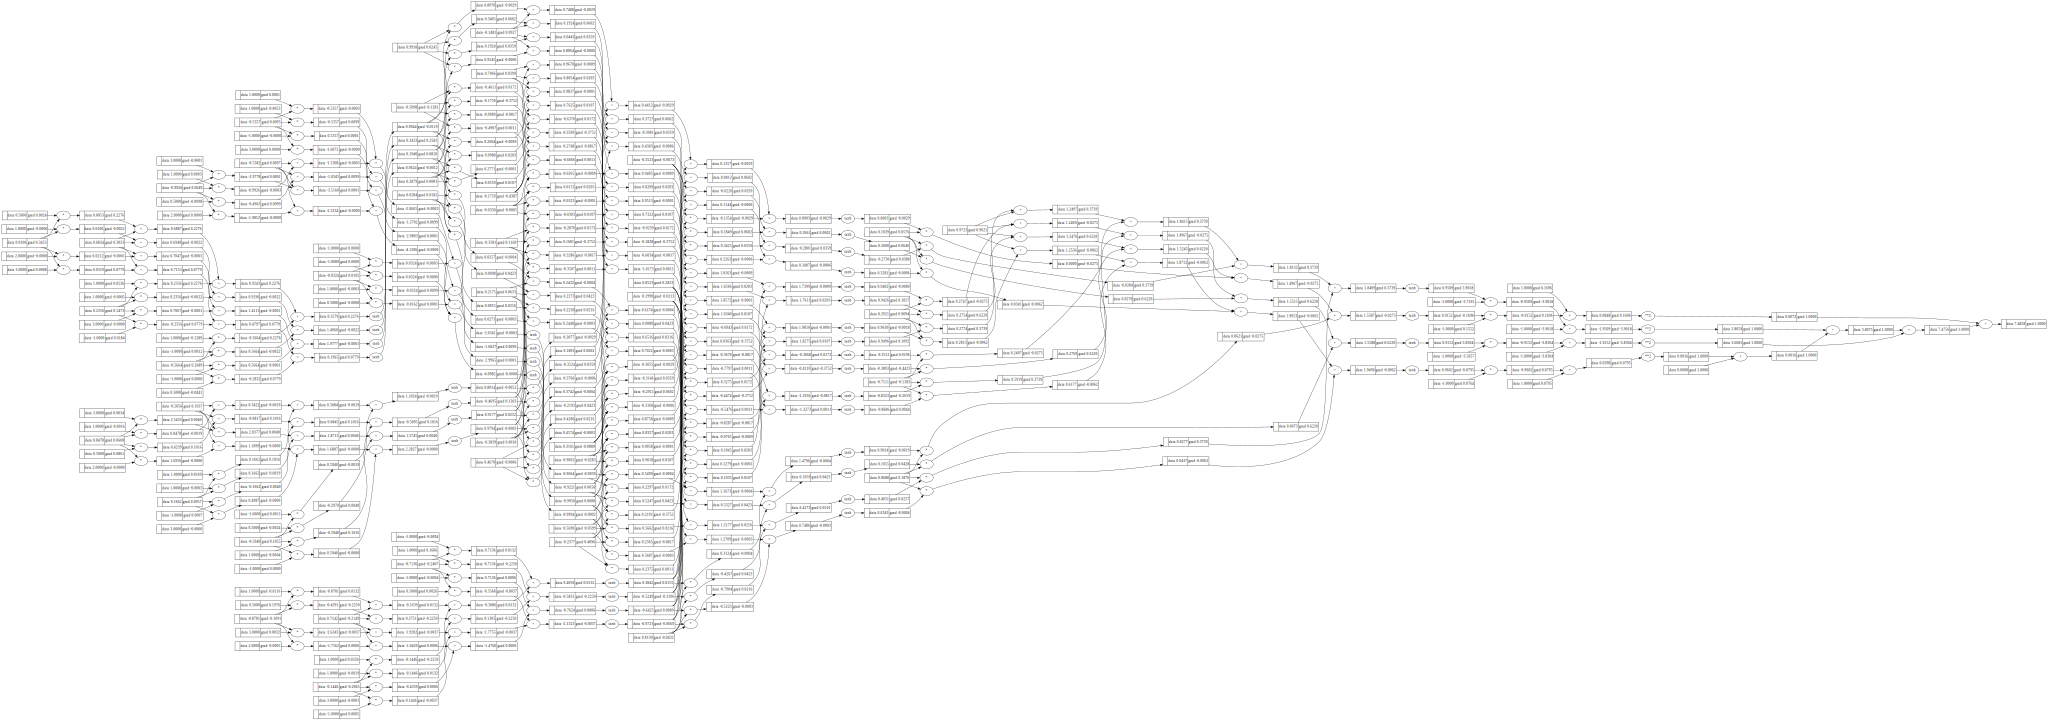

In [103]:
draw_dot(loss)

In [104]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [113]:
n.parameters()

[Value(data=0.7015953513376674),
 Value(data=-0.6969316925295868),
 Value(data=0.7413651143373916),
 Value(data=-0.7868490838133317),
 Value(data=-0.6264194263638341),
 Value(data=0.17809696292143196),
 Value(data=0.9054814922295755),
 Value(data=0.8867965692807087),
 Value(data=-0.7863660160944896),
 Value(data=-0.3931448922052736),
 Value(data=0.12246560615309288),
 Value(data=-0.857865186218292),
 Value(data=-0.9524010328774692),
 Value(data=0.25560763790117624),
 Value(data=-0.8627071031508247),
 Value(data=-0.4756450566438186),
 Value(data=0.43312789393939255),
 Value(data=0.5069351855289601),
 Value(data=-0.39040433019820653),
 Value(data=0.8510677345602922),
 Value(data=-0.6183531328613705),
 Value(data=-0.7850628341246391),
 Value(data=-0.8424309335271147),
 Value(data=0.6116352462419881),
 Value(data=0.22687241903041877),
 Value(data=0.44198700997415785),
 Value(data=-0.5306550923366524),
 Value(data=-0.8399794358075334),
 Value(data=0.5618501233223969),
 Value(data=0.65666969

In [112]:
len(n.parameters())

41

In [111]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.5891872672122789)

In [114]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.5891872672122789),
 Value(data=-0.6182530124310311),
 Value(data=-0.748843897933754),
 Value(data=0.5989950515949527)]

In [120]:
loss = sum((Value(ygt) - yout)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.01328425168095264)

In [116]:
loss.backward()

In [117]:
n.layers[0].neurons[0].w[0].grad

0.01179098132677104

In [118]:
n.layers[0].neurons[0].w[0].data

0.7015953513376674

In [121]:
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # important
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 0.012631078348752505
1 0.012038129357390218
2 0.011497483302262525
3 0.011002546743264972
4 0.010547787404520977
5 0.010128529178174635
6 0.0097407928547661
7 0.009381171110634034
8 0.009046729456416588
9 0.00873492706952823
10 0.00844355300633768
11 0.00817067441906272
12 0.007914594222881646
13 0.007673816261501476
14 0.007447016466772845
15 0.007233018843176256
16 0.007030775361491146
17 0.006839349039262808
18 0.006657899634267178
19 0.006485671492247014
